In [ ]:
!pip install numpy pandas scipy scikit-learn

In [ ]:
import pandas as pd
df = pd.read_csv(r"/content/vanderpol_dataset_final.csv")
print("\nFirst 5 Rows:")
print(df.head())
mu_counts = df['mu'].value_counts().sort_index()
print("\n===================================")
print("SAMPLES PER MU VALUE")
print("===================================\n")
for mu, count in mu_counts.items():
    print(f"mu = {mu:<12} --> {count} samples")
print("\n===================================")
print(f"TOTAL SAMPLES = {len(df)}")
print("===================================")


First 5 Rows:
    mu  std_y     rms_y    rms_dy   rms_ddy  energy_y  signal_power  \
0  0.0    1.0  0.994987  0.069691  0.028163      99.0          0.99   
1  0.0    1.0  0.994987  0.069646  0.028106      99.0          0.99   
2  0.0    1.0  0.994987  0.069854  0.027949      99.0          0.99   
3  0.0    1.0  0.994987  0.070052  0.027794      99.0          0.99   
4  0.0    1.0  0.994987  0.070020  0.027732      99.0          0.99   

   peak_to_peak  crest_factor  zero_crossings  entropy_y  skewness_y  \
0      2.800631      1.410987              27   6.199989    0.008039   
1      2.802040      1.411763              27   6.196231   -0.011897   
2      2.813039      1.423652              27   6.184394   -0.020269   
3      2.826270      1.435330              28   6.183825   -0.016781   
4      2.828724      1.435577              28   6.185046   -0.014026   

   kurtosis_y  mean_abs_y  shape_factor    regime  
0    1.497266    0.894638      1.112167  Harmonic  
1    1.500295    0.89

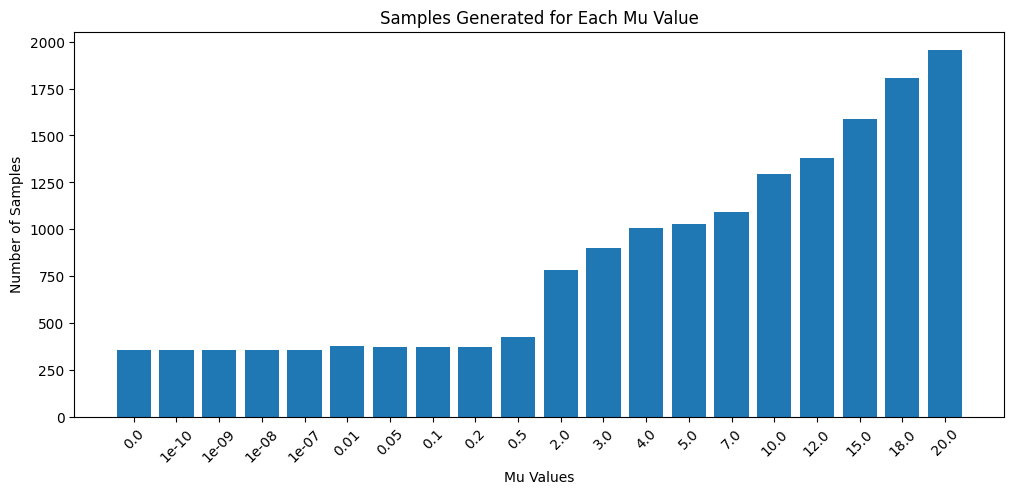

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.bar(mu_counts.index.astype(str), mu_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Mu Values')
plt.ylabel('Number of Samples')
plt.title('Samples Generated for Each Mu Value')
plt.show()

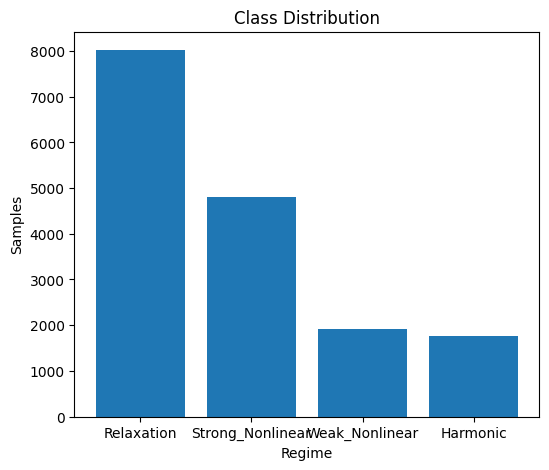

In [ ]:
class_counts = df['regime'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Regime')
plt.ylabel('Samples')
plt.title('Class Distribution')
plt.show()

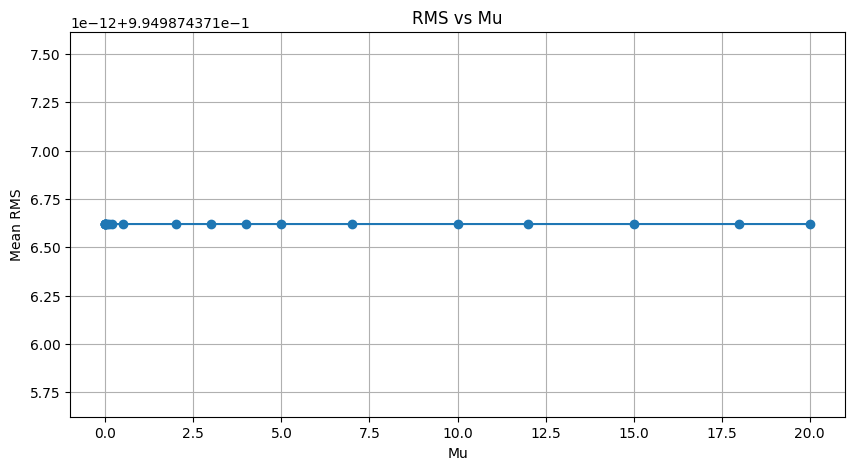

In [ ]:
rms_mu = df.groupby('mu')['rms_y'].mean()
plt.figure(figsize=(10,5))
plt.plot(rms_mu.index, rms_mu.values, marker='o')
plt.xlabel('Mu')
plt.ylabel('Mean RMS')
plt.title('RMS vs Mu')
plt.grid(True)
plt.show()

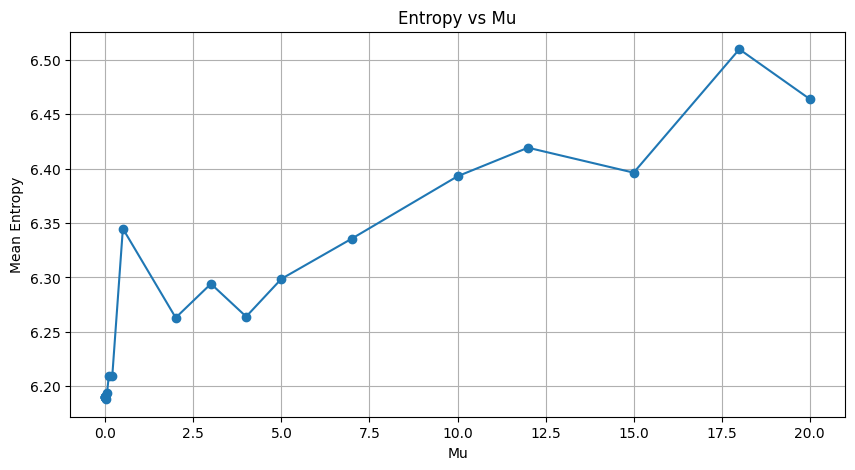

In [ ]:
entropy_mu = df.groupby('mu')['entropy_y'].mean()
plt.figure(figsize=(10,5))
plt.plot(entropy_mu.index, entropy_mu.values, marker='o')
plt.xlabel('Mu')
plt.ylabel('Mean Entropy')
plt.title('Entropy vs Mu')
plt.grid(True)
plt.show()

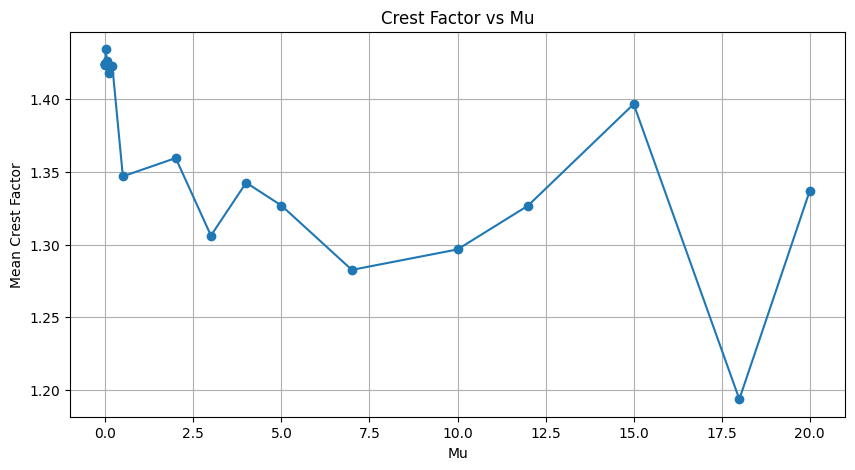

In [ ]:
crest_mu = df.groupby('mu')['crest_factor'].mean()
plt.figure(figsize=(10,5))
plt.plot(crest_mu.index, crest_mu.values, marker='o')
plt.xlabel('Mu')
plt.ylabel('Mean Crest Factor')
plt.title('Crest Factor vs Mu')
plt.grid(True)
plt.show()

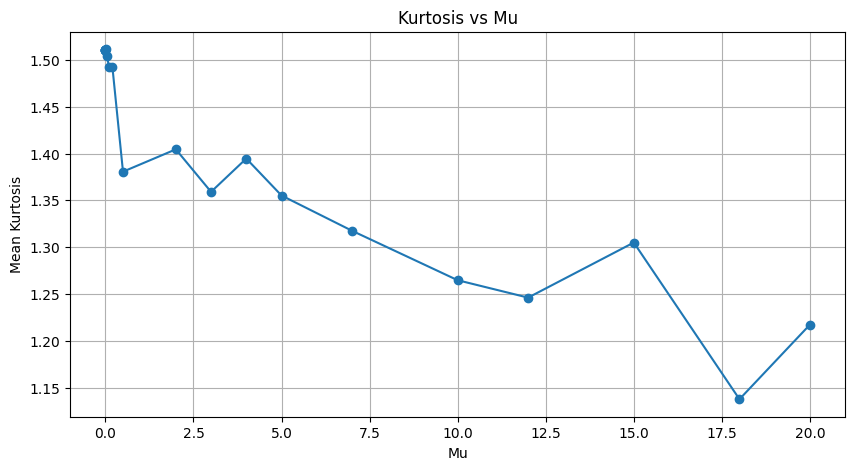

In [ ]:
kurt_mu = df.groupby('mu')['kurtosis_y'].mean()
plt.figure(figsize=(10,5))
plt.plot(kurt_mu.index, kurt_mu.values, marker='o')
plt.xlabel('Mu')
plt.ylabel('Mean Kurtosis')
plt.title('Kurtosis vs Mu')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("/content/vanderpol_dataset_final.csv")
train_mu = [
    # Harmonic
    0,
    1e-10,
    1e-9,
    # Weak Nonlinear
    0.01,
    0.05,
    0.1,
    # Strong Nonlinear
    2,
    3,
    4,
    # Relaxation
    10,
    12,
    15
]
test_mu = [
    # Harmonic
    1e-8,
    1e-7,
    # Weak Nonlinear
    0.2,
    0.5,
    # Strong Nonlinear
    5,
    7,
    # Relaxation
    18,
    20
]
train_df = df[df['mu'].isin(train_mu)].copy()
test_df = df[df['mu'].isin(test_mu)].copy()
train_mu_counts = train_df['mu'].value_counts().sort_index()

print("===================================")
print("ORIGINAL TRAIN SAMPLES PER MU")
print("===================================\n")

for mu, count in train_mu_counts.items():
    print(f"mu = {mu:<12} --> {count} samples")
min_mu_count = train_mu_counts.min()
print("\nMinimum samples among train mu values =", min_mu_count)

# BALANCE TRAIN SET PER MU
balanced_train_df = (
    train_df.groupby('mu', group_keys=False)
    .apply(lambda x: x.sample(min_mu_count, random_state=42))
)

# Shuffle dataset
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# DISPLAY FINAL TRAIN MU COUNTS
print("\n===================================")
print("BALANCED TRAIN SAMPLES PER MU")
print("===================================\n")

balanced_mu_counts = balanced_train_df['mu'].value_counts().sort_index()

for mu, count in balanced_mu_counts.items():
    print(f"mu = {mu:<12} --> {count} samples")

# CLASS DISTRIBUTION
print("\n===================================")
print("BALANCED TRAIN CLASS DISTRIBUTION")
print("===================================")

print(balanced_train_df['regime'].value_counts())

# TEST SET DISTRIBUTION
print("\n===================================")
print("TEST CLASS DISTRIBUTION")
print("===================================")

print(test_df['regime'].value_counts())

# TEST MU COUNTS
print("\n===================================")
print("TEST SAMPLES PER MU")
print("===================================\n")

test_mu_counts = test_df['mu'].value_counts().sort_index()

for mu, count in test_mu_counts.items():
    print(f"mu = {mu:<12} --> {count} samples")

# SAVE DATASETS
balanced_train_df.to_csv("balanced_train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)

print("\n===================================")
print("FINAL DATASETS SAVED")
print("===================================")

ORIGINAL TRAIN SAMPLES PER MU

mu = 0.0          --> 354 samples
mu = 1e-10        --> 354 samples
mu = 1e-09        --> 354 samples
mu = 0.01         --> 375 samples
mu = 0.05         --> 373 samples
mu = 0.1          --> 372 samples
mu = 2.0          --> 780 samples
mu = 3.0          --> 900 samples
mu = 4.0          --> 1006 samples
mu = 10.0         --> 1294 samples
mu = 12.0         --> 1378 samples
mu = 15.0         --> 1588 samples

Minimum samples among train mu values = 354

BALANCED TRAIN SAMPLES PER MU

mu = 0.0          --> 354 samples
mu = 1e-10        --> 354 samples
mu = 1e-09        --> 354 samples
mu = 0.01         --> 354 samples
mu = 0.05         --> 354 samples
mu = 0.1          --> 354 samples
mu = 2.0          --> 354 samples
mu = 3.0          --> 354 samples
mu = 4.0          --> 354 samples
mu = 10.0         --> 354 samples
mu = 12.0         --> 354 samples
mu = 15.0         --> 354 samples

BALANCED TRAIN CLASS DISTRIBUTION
regime
Harmonic            1062
Stron

/tmp/ipykernel_2254/2214623313.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_mu_count, random_state=42))



FINAL DATASETS SAVED


TRAIN DATASET SHAPE
(4248, 16)

TEST DATASET SHAPE
(7386, 16)

FEATURES USED
Index(['std_y', 'rms_y', 'rms_dy', 'rms_ddy', 'energy_y', 'signal_power',
       'peak_to_peak', 'crest_factor', 'zero_crossings', 'entropy_y',
       'skewness_y', 'kurtosis_y', 'mean_abs_y', 'shape_factor'],
      dtype='object')


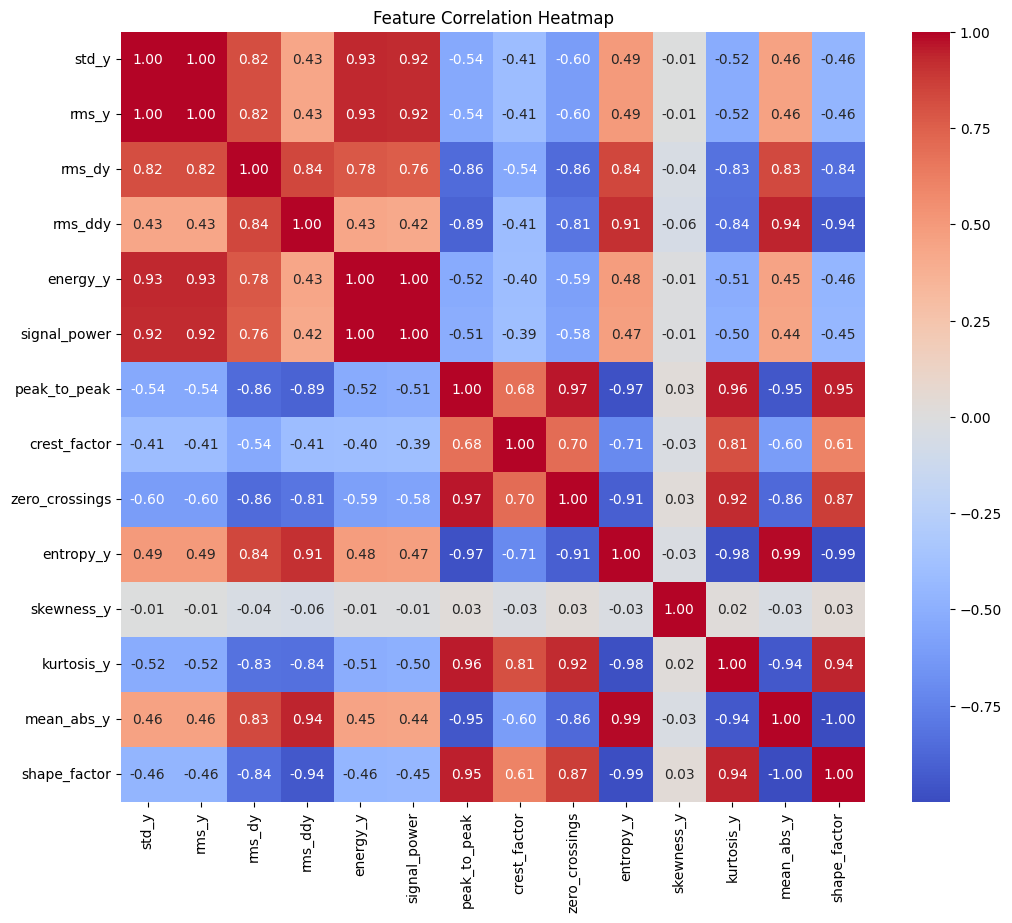

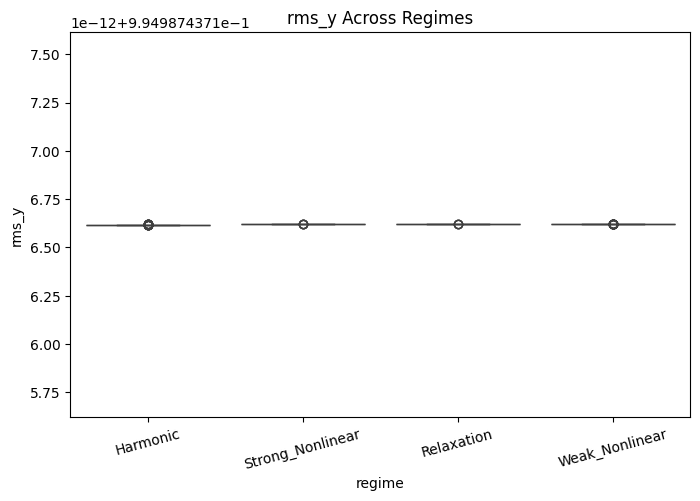

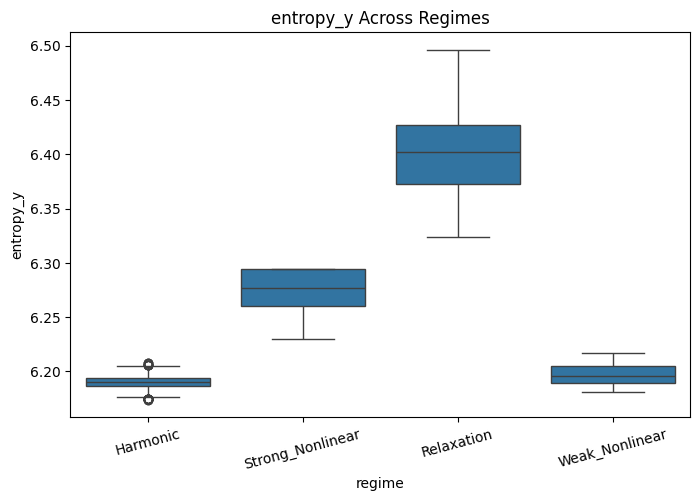

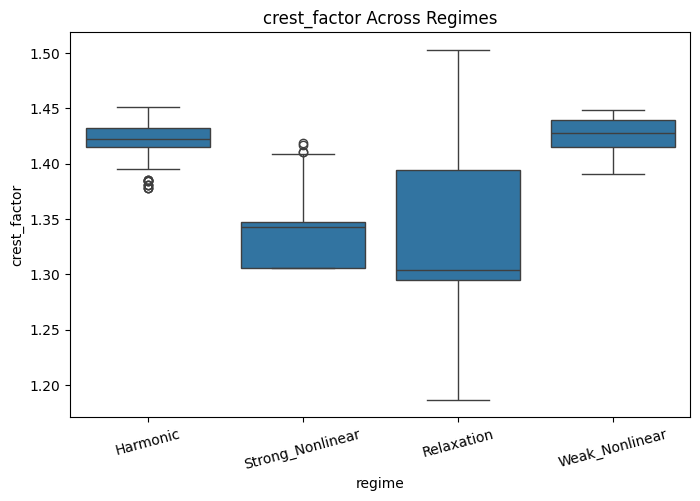

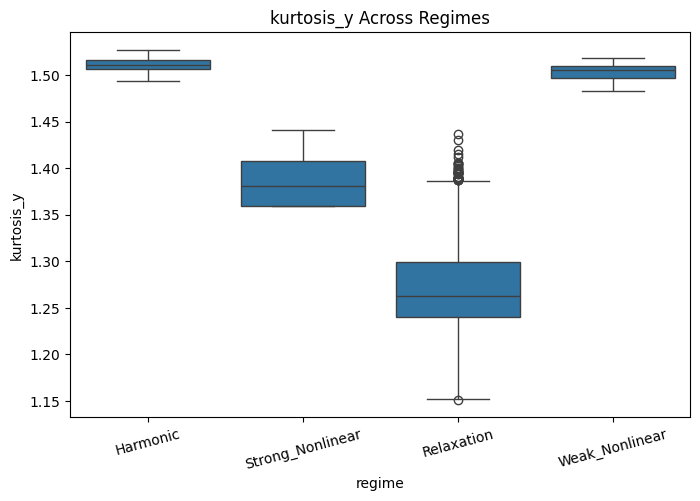


FEATURE SCALING COMPLETED


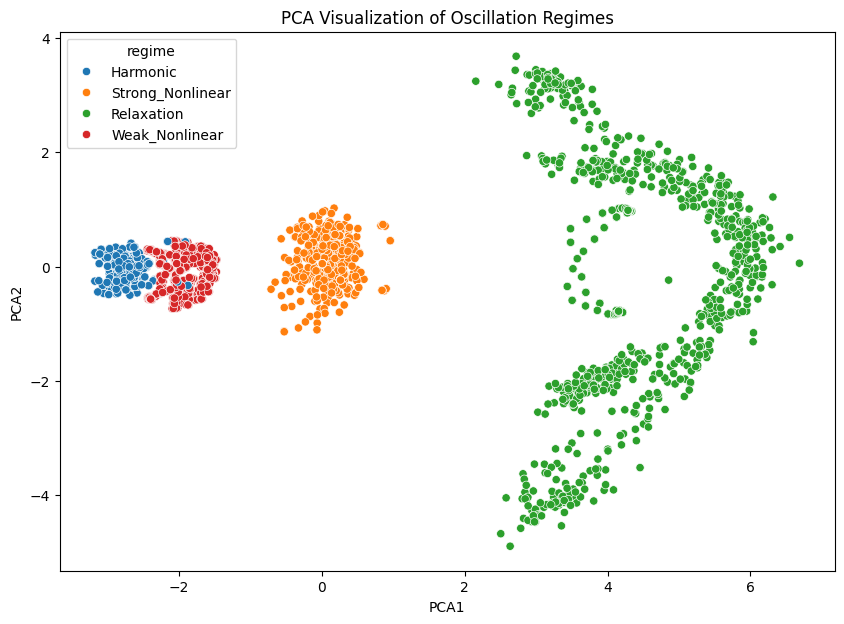


PCA EXPLAINED VARIANCE
[0.78347077 0.10106066]

Total Explained Variance = 0.8845314225915892

ML PREPROCESSING COMPLETED


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

train_df = pd.read_csv('balanced_train_dataset.csv')
test_df = pd.read_csv('test_dataset.csv')
print("===================================")
print("TRAIN DATASET SHAPE")
print("===================================")
print(train_df.shape)

print("\n===================================")
print("TEST DATASET SHAPE")
print("===================================")
print(test_df.shape)


X_train = train_df.drop(columns=['mu', 'regime'])
y_train = train_df['regime']
X_test = test_df.drop(columns=['mu', 'regime'])
y_test = test_df['regime']
feature_names = X_train.columns

print("\n===================================")
print("FEATURES USED")
print("===================================")

print(feature_names)

# CORRELATION HEATMAP
plt.figure(figsize=(12,10))
correlation_matrix = X_train.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Feature Correlation Heatmap')
plt.show()

# BOXPLOTS FOR IMPORTANT FEATURES
important_features = [
    'rms_y',
    'entropy_y',
    'crest_factor',
    'kurtosis_y'
]

for feature in important_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x='regime',
        y=feature,
        data=train_df
    )
    plt.title(f'{feature} Across Regimes')
    plt.xticks(rotation=15)
    plt.show()

# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n===================================")
print("FEATURE SCALING COMPLETED")
print("===================================")

# PCA VISUALIZATION
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame()
pca_df['PCA1'] = X_train_pca[:,0]
pca_df['PCA2'] = X_train_pca[:,1]
pca_df['regime'] = y_train.values

# Plot PCA
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='regime',
    data=pca_df
)

plt.title('PCA Visualization of Oscillation Regimes')

plt.show()

# DISPLAY PCA VARIANCE
print("\n===================================")
print("PCA EXPLAINED VARIANCE")
print("===================================")

print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance =",
      np.sum(pca.explained_variance_ratio_))

print("\n===================================")
print("ML PREPROCESSING COMPLETED")
print("===================================")

In [ ]:
import numpy as np
import pandas as pd
import time
import warnings

from scipy.stats import loguniform

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelBinarizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    PassiveAggressiveClassifier,
    Perceptron
)
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)

if "X_train" not in globals() or "y_train" not in globals():
    raise ValueError(
        "Run the preprocessing cell to create X_train/X_test and y_train/y_test."
    )

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Tuning budget per model; increase n_iter if you want deeper search.
DEFAULT_N_ITER = 12


def build_pipeline(estimator, scaler):
    steps = []
    if scaler == "standard":
        steps.append(("scaler", StandardScaler()))
    elif scaler == "minmax":
        steps.append(("scaler", MinMaxScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)


def get_score_values(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores
    return None


def compute_metrics(model, X, y_true):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    scores = get_score_values(model, X)
    auc_ovr = np.nan
    if scores is not None:
        lb = LabelBinarizer()
        y_bin = lb.fit_transform(y_true)
        if y_bin.ndim == 1:
            y_bin = y_bin.reshape(-1, 1)
        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
        if y_bin.shape[1] == 1:
            y_bin = np.hstack([1 - y_bin, y_bin])
        if scores.shape[1] == 1:
            scores = np.hstack([1 - scores, scores])
        try:
            if y_bin.shape[1] > 2:
                auc_ovr = roc_auc_score(
                    y_bin,
                    scores,
                    average="macro",
                    multi_class="ovr"
                )
            else:
                auc_ovr = roc_auc_score(y_bin[:, 1], scores[:, 1])
        except Exception:
            auc_ovr = np.nan

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "precision_macro": precision_m,
        "recall_macro": recall_m,
        "f1_macro": f1_m,
        "roc_auc_ovr": auc_ovr
    }


model_configs = [
    {
        "name": "Logistic Regression",
        "estimator": LogisticRegression(
            max_iter=5000,
            random_state=42,
            solver="liblinear"
        ),
        "params": {
            "model__C": loguniform(1e-3, 1e2),
            "model__penalty": ["l1", "l2"]
        },
        "scaler": "standard",
        "n_iter": 15
    },
    {
        "name": "Ridge Classifier",
        "estimator": RidgeClassifier(random_state=42),
        "params": {
            "model__alpha": loguniform(1e-3, 1e2)
        },
        "scaler": "standard",
        "n_iter": DEFAULT_N_ITER
    },
    {
        "name": "SGD Classifier",
        "estimator": SGDClassifier(
            max_iter=2000,
            random_state=42
        ),
        "params": {
            "model__loss": ["hinge", "log_loss", "modified_huber"],
            "model__alpha": loguniform(1e-5, 1e-1),
            "model__penalty": ["l2", "l1", "elasticnet"],
            "model__learning_rate": ["optimal", "adaptive"]
        },
        "scaler": "standard",
        "n_iter": 18
    },
    {
        "name": "Passive Aggressive",
        "estimator": PassiveAggressiveClassifier(
            max_iter=2000,
            random_state=42
        ),
        "params": {
            "model__C": loguniform(1e-3, 10),
            "model__loss": ["hinge", "squared_hinge"]
        },
        "scaler": "standard",
        "n_iter": DEFAULT_N_ITER
    },
    {
        "name": "Perceptron",
        "estimator": Perceptron(
            max_iter=2000,
            random_state=42
        ),
        "params": {
            "model__alpha": loguniform(1e-5, 1e-2),
            "model__penalty": ["l2", "l1", "elasticnet"]
        },
        "scaler": "standard",
        "n_iter": DEFAULT_N_ITER
    },
    {
        "name": "Linear SVM",
        "estimator": LinearSVC(random_state=42),
        "params": {
            "model__C": loguniform(1e-3, 1e2)
        },
        "scaler": "standard",
        "n_iter": 12
    },
    {
        "name": "SVM (RBF)",
        "estimator": SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),
        "params": {
            "model__C": loguniform(1e-2, 1e2),
            "model__gamma": loguniform(1e-4, 1e-1)
        },
        "scaler": "standard",
        "n_iter": 10
    },
    {
        "name": "NuSVC (RBF)",
        "estimator": NuSVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),
        "params": {
            "model__nu": [0.1, 0.3, 0.5, 0.7],
            "model__gamma": loguniform(1e-4, 1e-1)
        },
        "scaler": "standard",
        "n_iter": 10
    },
    {
        "name": "KNN",
        "estimator": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        },
        "scaler": "standard",
        "n_iter": DEFAULT_N_ITER
    },
    {
        "name": "Nearest Centroid",
        "estimator": NearestCentroid(),
        "params": {
            "model__metric": ["euclidean", "manhattan"]
        },
        "scaler": "standard",
        "n_iter": 4
    },
    {
        "name": "LDA",
        "estimator": LinearDiscriminantAnalysis(solver="lsqr"),
        "params": {
            "model__shrinkage": [None, "auto", 0.1, 0.5, 0.9]
        },
        "scaler": "standard",
        "n_iter": 8
    },
    {
        "name": "QDA",
        "estimator": QuadraticDiscriminantAnalysis(),
        "params": {
            "model__reg_param": [0.0, 0.1, 0.2, 0.3, 0.5]
        },
        "scaler": "standard",
        "n_iter": 8
    },
    {
        "name": "Gaussian NB",
        "estimator": GaussianNB(),
        "params": {
            "model__var_smoothing": loguniform(1e-12, 1e-7)
        },
        "scaler": "none",
        "n_iter": 10
    },
    {
        "name": "Bernoulli NB",
        "estimator": BernoulliNB(),
        "params": {
            "model__alpha": loguniform(1e-3, 10),
            "model__binarize": [0.0, 0.3, 0.5]
        },
        "scaler": "minmax",
        "n_iter": 10
    },
    {
        "name": "Multinomial NB",
        "estimator": MultinomialNB(),
        "params": {
            "model__alpha": loguniform(1e-3, 10)
        },
        "scaler": "minmax",
        "n_iter": 10
    },
    {
        "name": "Decision Tree",
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 3, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        },
        "scaler": "none",
        "n_iter": 15
    },
    {
        "name": "Random Forest",
        "estimator": RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),
        "params": {
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        "scaler": "none",
        "n_iter": 15
    },
    {
        "name": "Extra Trees",
        "estimator": ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),
        "params": {
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        "scaler": "none",
        "n_iter": 15
    },
    {
        "name": "Gradient Boosting",
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0]
        },
        "scaler": "none",
        "n_iter": 12
    },
    {
        "name": "Hist Gradient Boosting",
        "estimator": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "model__max_iter": [100, 200, 300],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [None, 6, 10],
            "model__l2_regularization": [0.0, 0.1, 1.0]
        },
        "scaler": "none",
        "n_iter": 12
    },
    {
        "name": "AdaBoost",
        "estimator": AdaBoostClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.5, 1.0, 1.5]
        },
        "scaler": "none",
        "n_iter": 10
    },
    {
        "name": "Bagging (Tree)",
        "estimator": BaggingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_samples": [0.5, 0.8, 1.0],
            "model__max_features": [0.5, 0.8, 1.0]
        },
        "scaler": "none",
        "n_iter": 10
    },
    {
        "name": "MLP (Shallow)",
        "estimator": MLPClassifier(
            max_iter=600,
            random_state=42
        ),
        "params": {
            "model__hidden_layer_sizes": [(64,), (128,), (64, 64)],
            "model__alpha": loguniform(1e-5, 1e-2),
            "model__learning_rate_init": loguniform(1e-4, 1e-2)
        },
        "scaler": "standard",
        "n_iter": 12
    },
    {
        "name": "MLP (Deep)",
        "estimator": MLPClassifier(
            max_iter=800,
            random_state=42
        ),
        "params": {
            "model__hidden_layer_sizes": [
                (256, 128, 64),
                (128, 128, 64),
                (256, 128)
            ],
            "model__alpha": loguniform(1e-5, 1e-2),
            "model__learning_rate_init": loguniform(1e-4, 1e-2)
        },
        "scaler": "standard",
        "n_iter": 12
    },
    {
        "name": "MLP (Wide)",
        "estimator": MLPClassifier(
            max_iter=800,
            random_state=42
        ),
        "params": {
            "model__hidden_layer_sizes": [(512, 256), (512, 128)],
            "model__alpha": loguniform(1e-5, 1e-2),
            "model__learning_rate_init": loguniform(1e-4, 1e-2)
        },
        "scaler": "standard",
        "n_iter": 10
    }
]


results = []
best_params = []

print("===================================")
print("TUNING AND TRAINING MODELS")
print("===================================\n")

for idx, cfg in enumerate(model_configs, start=1):
    print(f"[{idx}/{len(model_configs)}] {cfg['name']}")

    estimator = build_pipeline(cfg["estimator"], cfg["scaler"])
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="f1_weighted",
        n_jobs=-1,
        cv=cv,
        random_state=42,
        refit=True
    )

    start_fit = time.perf_counter()
    search.fit(X_train, y_train)
    fit_time = time.perf_counter() - start_fit

    best_model = search.best_estimator_

    start_pred = time.perf_counter()
    metrics = compute_metrics(best_model, X_test, y_test)
    pred_time = time.perf_counter() - start_pred

    results.append({
        "model": cfg["name"],
        "cv_f1_weighted": search.best_score_,
        "accuracy": metrics["accuracy"],
        "precision_weighted": metrics["precision_weighted"],
        "recall_weighted": metrics["recall_weighted"],
        "f1_weighted": metrics["f1_weighted"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "roc_auc_ovr": metrics["roc_auc_ovr"],
        "fit_time_s": fit_time,
        "predict_time_s": pred_time
    })

    best_params.append({
        "model": cfg["name"],
        "best_params": search.best_params_,
        "cv_f1_weighted": search.best_score_
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_weighted", ascending=False)

best_params_df = pd.DataFrame(best_params)
best_params_df = best_params_df.sort_values(by="cv_f1_weighted", ascending=False)

pd.set_option("display.max_colwidth", 200)

print("\n===================================")
print("MODEL COMPARISON (SORTED BY F1-WEIGHTED)")
print("===================================")
print(results_df)

print("\n===================================")
print("BEST HYPERPARAMETERS")
print("===================================")
print(best_params_df)

print("\n===================================")
print(f"TOTAL MODELS TRAINED = {len(results_df)}")
print("===================================")

# Optional: export to CSV for reporting
results_df.to_csv("model_comparison_metrics.csv", index=False)
best_params_df.to_csv("model_best_params.csv", index=False)

print("\nSaved: model_comparison_metrics.csv and model_best_params.csv")

TUNING AND TRAINING MODELS

[1/25] Logistic Regression
[2/25] Ridge Classifier
[3/25] SGD Classifier
[4/25] Passive Aggressive
[5/25] Perceptron
[6/25] Linear SVM
[7/25] SVM (RBF)
[8/25] NuSVC (RBF)
[9/25] KNN
[10/25] Nearest Centroid
[11/25] LDA
[12/25] QDA
[13/25] Gaussian NB
[14/25] Bernoulli NB
[15/25] Multinomial NB
[16/25] Decision Tree
[17/25] Random Forest
[18/25] Extra Trees
[19/25] Gradient Boosting
[20/25] Hist Gradient Boosting
[21/25] AdaBoost
[22/25] Bagging (Tree)
[23/25] MLP (Shallow)
[24/25] MLP (Deep)
[25/25] MLP (Wide)

MODEL COMPARISON (SORTED BY F1-WEIGHTED)
                     model  cv_f1_weighted  accuracy  precision_weighted  \
1         Ridge Classifier        1.000000  0.997021            0.997039   
0      Logistic Regression        1.000000  0.962767            0.965304   
10                     LDA        1.000000  0.958029            0.961225   
2           SGD Classifier        1.000000  0.939480            0.948689   
3       Passive Aggressive        

TOTAL FEATURES
['std_y', 'rms_y', 'rms_dy', 'rms_ddy', 'energy_y', 'signal_power', 'peak_to_peak', 'crest_factor', 'zero_crossings', 'entropy_y', 'skewness_y', 'kurtosis_y', 'mean_abs_y', 'shape_factor']

RUNNING GA MULTIPLE TIMES
GA Run 1
GA Run 2
GA Run 3
GA Run 4
GA Run 5

RUNNING PSO MULTIPLE TIMES
PSO Run 1
PSO Run 2
PSO Run 3
PSO Run 4
PSO Run 5

GA vs PSO COMPARATIVE ANALYSIS
  Method  Best Accuracy  Mean Accuracy  Std Accuracy  Runtime (s)  \
0     GA       0.980774       0.962415      0.012861    31.234560   
1    PSO       0.980774       0.978040      0.005470    30.754242   

   Selected Features  Feature Reduction %  95% Convergence Iteration  
0                  2            85.714286                          1  
1                  4            71.428571                          2  

COMMON IMPORTANT FEATURES
{'rms_ddy'}


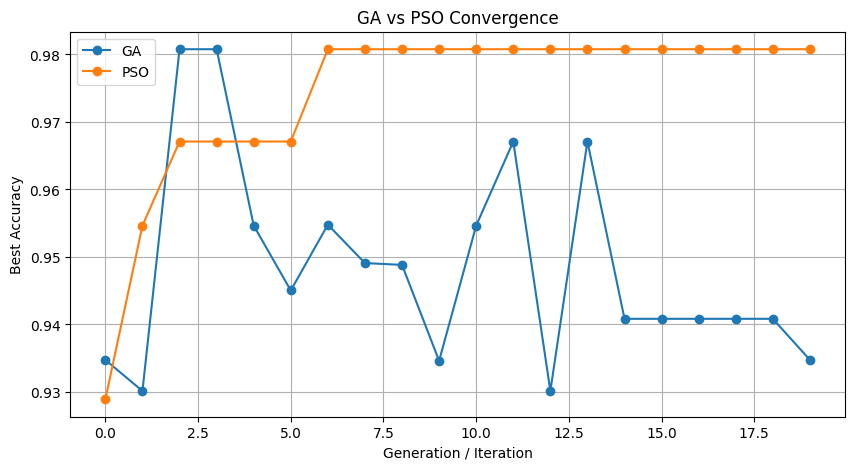

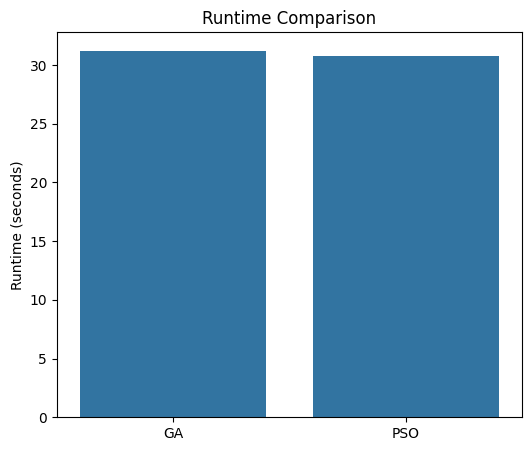

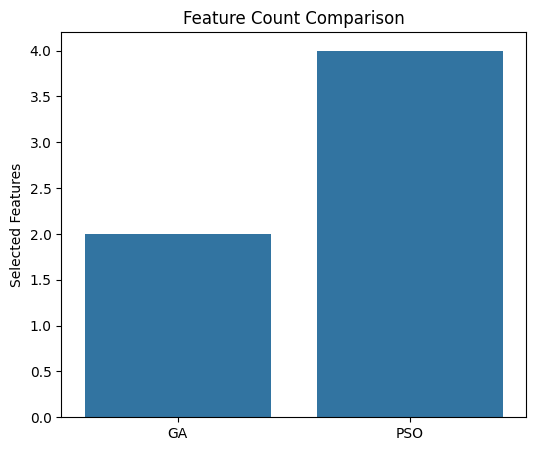

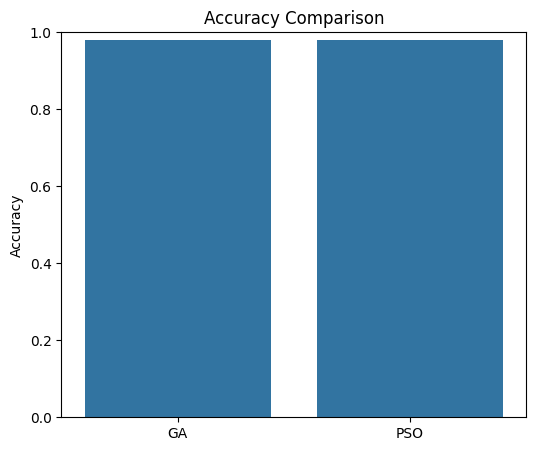

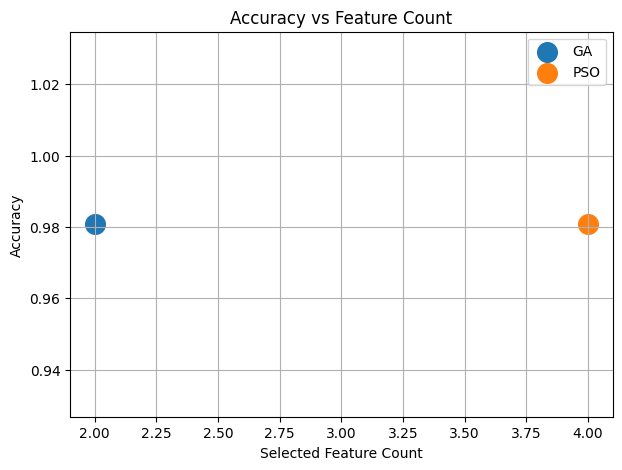


BEST GA FEATURES
['std_y', 'rms_ddy']

BEST PSO FEATURES
['rms_y', 'rms_ddy', 'energy_y', 'signal_power']


In [ ]:
import numpy as np
import pandas as pd
import random
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# FEATURE INFORMATION
feature_names = X_train.columns.tolist()
num_features = len(feature_names)

print("===================================")
print("TOTAL FEATURES")
print("===================================")

print(feature_names)

# FITNESS FUNCTION
def fitness_function(binary_vector):

    selected_indices = [

        i for i in range(num_features)

        if binary_vector[i] == 1
    ]

    # Avoid empty feature set
    if len(selected_indices) == 0:

        return 0

    X_train_selected = X_train_scaled[:, selected_indices]

    X_test_selected = X_test_scaled[:, selected_indices]

    model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

# GENETIC ALGORITHM FUNCTION
def run_ga():
    population_size = 20
    num_generations = 20
    mutation_rate = 0.1
    start_time = time.time()

    # Initial population
    population = []
    for _ in range(population_size):

        chromosome = np.random.randint(
            0,
            2,
            num_features
        )

        population.append(chromosome)

    best_accuracy = 0
    best_chromosome = None
    convergence_history = []

    for generation in range(num_generations):
        fitness_scores = []
        for chromosome in population:
            acc = fitness_function(chromosome)
            fitness_scores.append(acc)
        fitness_scores = np.array(fitness_scores)
        best_idx = np.argmax(fitness_scores)
        generation_best_accuracy = fitness_scores[best_idx]
        convergence_history.append(generation_best_accuracy)

        # Update best
        if generation_best_accuracy > best_accuracy:
            best_accuracy = generation_best_accuracy
            best_chromosome = population[best_idx].copy()

        # TOURNAMENT SELECTION
        selected_population = []

        for _ in range(population_size):
            idx1 = random.randint(0, population_size-1)
            idx2 = random.randint(0, population_size-1)

            if fitness_scores[idx1] > fitness_scores[idx2]:
                winner = population[idx1]

            else:
                winner = population[idx2]
            selected_population.append(winner)

        # CROSSOVER
        new_population = []

        for i in range(0, population_size, 2):
            parent1 = selected_population[i]
            parent2 = selected_population[i+1]

            crossover_point = random.randint(
                1,
                num_features-1
            )

            child1 = np.concatenate([
                parent1[:crossover_point],
                parent2[crossover_point:]
            ])

            child2 = np.concatenate([
                parent2[:crossover_point],
                parent1[crossover_point:]
            ])

            new_population.extend([child1, child2])

        # MUTATION

        for chromosome in new_population:
            for gene_idx in range(num_features):
                if random.random() < mutation_rate:
                    chromosome[gene_idx] = 1 - chromosome[gene_idx]

        population = new_population

    end_time = time.time()
    runtime = end_time - start_time

    selected_features = [
        feature_names[i]
        for i in range(num_features)
        if best_chromosome[i] == 1
    ]

    return {
        'accuracy': best_accuracy,
        'features': selected_features,
        'feature_count': len(selected_features),
        'history': convergence_history,
        'runtime': runtime
    }

# ============================================================
# PSO FUNCTION
# ============================================================

def run_pso():
    num_particles = 20
    num_iterations = 20
    w = 0.7
    c1 = 1.5
    c2 = 1.5

    start_time = time.time()

    particles = np.random.randint(
        0,
        2,
        (num_particles, num_features)
    )

    velocities = np.random.uniform(
        -1,
        1,
        (num_particles, num_features)
    )

    pbest_positions = particles.copy()
    pbest_scores = np.array([

        fitness_function(p)
        for p in particles
    ])

    gbest_idx = np.argmax(pbest_scores)
    gbest_position = pbest_positions[gbest_idx].copy()
    gbest_score = pbest_scores[gbest_idx]
    convergence_history = []

    for iteration in range(num_iterations):
        convergence_history.append(gbest_score)
        for i in range(num_particles):
            r1 = np.random.rand(num_features)
            r2 = np.random.rand(num_features)

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - particles[i])
                + c2 * r2 * (gbest_position - particles[i])

            )
            sigmoid = 1 / (1 + np.exp(-velocities[i]))
            particles[i] = np.where(
                np.random.rand(num_features) < sigmoid,
                1,

                0
            )

            current_score = fitness_function(particles[i])

            # Update pbest
            if current_score > pbest_scores[i]:
                pbest_scores[i] = current_score
                pbest_positions[i] = particles[i].copy()

            # Update gbest
            if current_score > gbest_score:
                gbest_score = current_score
                gbest_position = particles[i].copy()

    end_time = time.time()

    runtime = end_time - start_time

    selected_features = [
        feature_names[i]
        for i in range(num_features)

        if gbest_position[i] == 1
    ]

    return {
        'accuracy': gbest_score,
        'features': selected_features,
        'feature_count': len(selected_features),
        'history': convergence_history,
        'runtime': runtime
    }

# MULTIPLE RUNS
ga_runs = []
pso_runs = []
num_runs = 5

print("\n===================================================")
print("RUNNING GA MULTIPLE TIMES")
print("===================================================")

for run in range(num_runs):
    print(f"GA Run {run+1}")
    ga_runs.append(run_ga())

print("\n===================================================")
print("RUNNING PSO MULTIPLE TIMES")
print("===================================================")

for run in range(num_runs):
    print(f"PSO Run {run+1}")
    pso_runs.append(run_pso())

# EXTRACT RESULTS
ga_accuracies = [r['accuracy'] for r in ga_runs]
pso_accuracies = [r['accuracy'] for r in pso_runs]
ga_runtimes = [r['runtime'] for r in ga_runs]
pso_runtimes = [r['runtime'] for r in pso_runs]
ga_feature_counts = [r['feature_count'] for r in ga_runs]
pso_feature_counts = [r['feature_count'] for r in pso_runs]

# BEST RUNS
best_ga = ga_runs[np.argmax(ga_accuracies)]
best_pso = pso_runs[np.argmax(pso_accuracies)]

# CONVERGENCE SPEED

def convergence_iteration(history):
    target = 0.95 * max(history)

    for idx, val in enumerate(history):
        if val >= target:

            return idx + 1

    return len(history)

ga_conv_iter = convergence_iteration(best_ga['history'])
pso_conv_iter = convergence_iteration(best_pso['history'])

# FEATURE REDUCTION

ga_reduction = (
    (num_features - best_ga['feature_count'])
    / num_features
) * 100

pso_reduction = (
    (num_features - best_pso['feature_count'])
    / num_features
) * 100
# FEATURE OVERLAP
ga_feature_set = set(best_ga['features'])
pso_feature_set = set(best_pso['features'])
common_features = ga_feature_set.intersection(pso_feature_set)

# COMPARISON TABLE
comparison_df = pd.DataFrame({

    'Method': ['GA', 'PSO'],

    'Best Accuracy': [
        max(ga_accuracies),
        max(pso_accuracies)
    ],

    'Mean Accuracy': [
        np.mean(ga_accuracies),
        np.mean(pso_accuracies)
    ],

    'Std Accuracy': [
        np.std(ga_accuracies),
        np.std(pso_accuracies)
    ],

    'Runtime (s)': [
        np.mean(ga_runtimes),
        np.mean(pso_runtimes)
    ],

    'Selected Features': [
        best_ga['feature_count'],
        best_pso['feature_count']
    ],

    'Feature Reduction %': [
        ga_reduction,
        pso_reduction
    ],

    '95% Convergence Iteration': [
        ga_conv_iter,
        pso_conv_iter
    ]
})

print("\n===================================================")
print("GA vs PSO COMPARATIVE ANALYSIS")
print("===================================================")

print(comparison_df)

# COMMON FEATURES
print("\n===================================================")
print("COMMON IMPORTANT FEATURES")
print("===================================================")

print(common_features)

# CONVERGENCE PLOT
plt.figure(figsize=(10,5))
plt.plot(
    best_ga['history'],
    marker='o',
    label='GA'
)

plt.plot(
    best_pso['history'],
    marker='o',
    label='PSO'
)

plt.xlabel('Generation / Iteration')
plt.ylabel('Best Accuracy')
plt.title('GA vs PSO Convergence')
plt.legend()
plt.grid(True)
plt.show()

# RUNTIME COMPARISON
plt.figure(figsize=(6,5))

sns.barplot(
    x=['GA','PSO'],
    y=[
        np.mean(ga_runtimes),
        np.mean(pso_runtimes)
    ]
)

plt.ylabel('Runtime (seconds)')
plt.title('Runtime Comparison')
plt.show()

# FEATURE COUNT COMPARISON
plt.figure(figsize=(6,5))

sns.barplot(
    x=['GA','PSO'],
    y=[
        best_ga['feature_count'],
        best_pso['feature_count']
    ]
)

plt.ylabel('Selected Features')
plt.title('Feature Count Comparison')

plt.show()

# ACCURACY COMPARISON
plt.figure(figsize=(6,5))

sns.barplot(
    x=['GA','PSO'],
    y=[
        max(ga_accuracies),
        max(pso_accuracies)
    ]
)

plt.ylim(0,1)

plt.ylabel('Accuracy')

plt.title('Accuracy Comparison')

plt.show()

# ACCURACY vs FEATURE COUNT
plt.figure(figsize=(7,5))

plt.scatter(
    best_ga['feature_count'],
    max(ga_accuracies),
    s=200,
    label='GA'
)

plt.scatter(
    best_pso['feature_count'],
    max(pso_accuracies),
    s=200,
    label='PSO'
)

plt.xlabel('Selected Feature Count')

plt.ylabel('Accuracy')

plt.title('Accuracy vs Feature Count')

plt.legend()

plt.grid(True)

plt.show()

print("\n===================================================")
print("BEST GA FEATURES")
print("===================================================")

print(best_ga['features'])

print("\n===================================================")
print("BEST PSO FEATURES")
print("===================================================")

print(best_pso['features'])